device: cuda


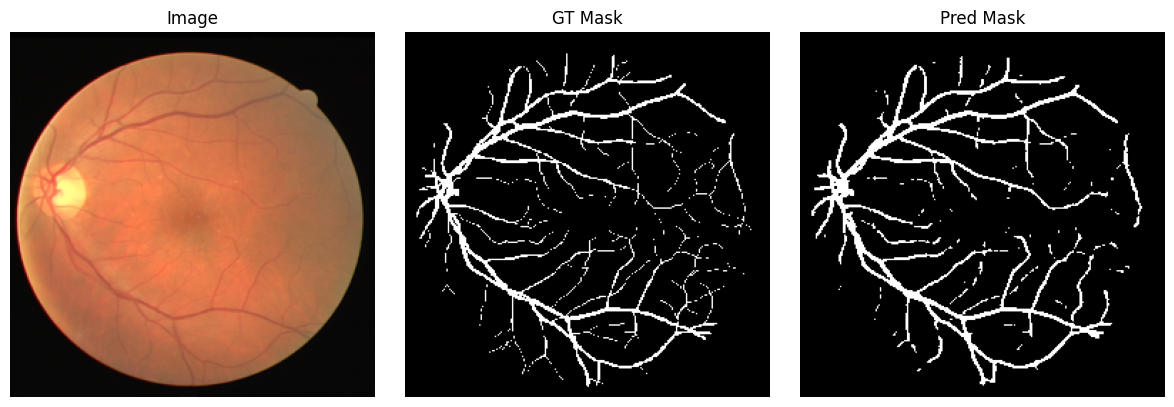

In [3]:
import torch
import matplotlib.pyplot as plt

from datasets.drive_dataset import DriveDataset
from models.mini_unet import MiniUNet


def predict():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device:", device)

    # ===== 1. 加载数据 =====
    dataset = DriveDataset(
        root_dir=r"E:\CS\PostG\个人\unet_learn\DRIVE\training",
        image_size=256
    )

    img, gt_mask = dataset[0]

    # (3,256,256) -> (1,3,256,256)
    img_tensor = img.unsqueeze(0).to(device)

    # ===== 2. 加载模型 =====
    model = MiniUNet(in_channels=3, num_classes=1).to(device)

    model.load_state_dict(torch.load("best_mini_unet_drive.pth", map_location=device))
    model.eval()

    # ===== 3. 推理 =====
    with torch.no_grad():
        logits = model(img_tensor)
        prob = torch.sigmoid(logits)
        pred_mask = (prob > 0.5).float()

    # ===== 4. 转回 CPU =====
    img = img.permute(1, 2, 0).numpy()  # (H,W,C)
    gt_mask = gt_mask.squeeze(0).numpy()
    pred_mask = pred_mask.squeeze().cpu().numpy()

    # ===== 5. 可视化 =====
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("GT Mask")
    plt.imshow(gt_mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Pred Mask")
    plt.imshow(pred_mask, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    predict()

device: cuda


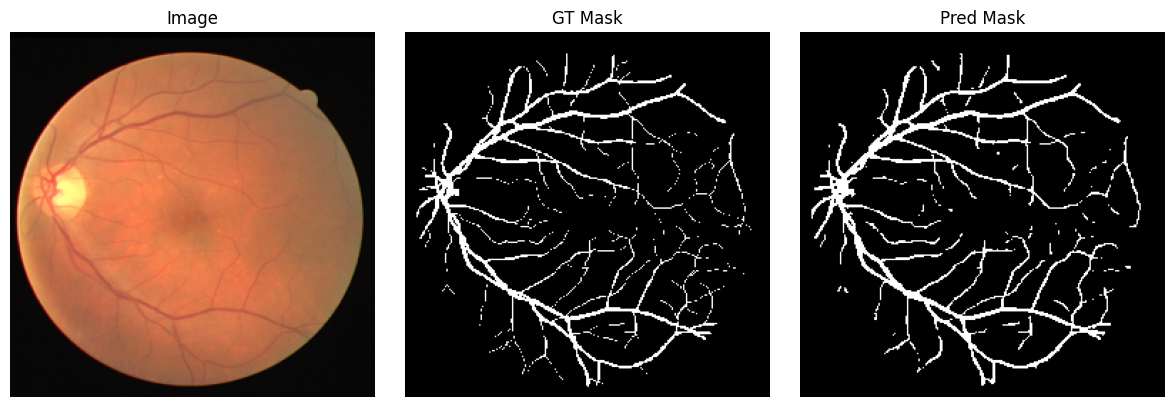

In [2]:
import torch
import matplotlib.pyplot as plt

from datasets.drive_dataset import DriveDataset
# from models.mini_unet import MiniUNet
from models.resunet import ResUNet


def predict():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device:", device)

    # ===== 1. 加载数据 =====
    dataset = DriveDataset(
        root_dir=r"E:\CS\PostG\个人\unet_learn\DRIVE\training",
        image_size=256
    )

    img, gt_mask = dataset[0]

    # (3,256,256) -> (1,3,256,256)
    img_tensor = img.unsqueeze(0).to(device)

    # ===== 2. 加载模型 =====
    # model = MiniUNet(in_channels=3, num_classes=1).to(device)
    model = ResUNet(num_classes=1).to(device)

    # model.load_state_dict(torch.load("best_mini_unet_drive.pth", map_location=device))
    model.load_state_dict(torch.load("E:\\CS\\PostG\\个人\\unet_learn\\checkpoints\\best_resunet_tversky_drive.pth", map_location=device))
    model.eval()

    # ===== 3. 推理 =====
    with torch.no_grad():
        logits = model(img_tensor)
        prob = torch.sigmoid(logits)
        pred_mask = (prob > 0.5).float()

    # ===== 4. 转回 CPU =====
    img = img.permute(1, 2, 0).numpy()  # (H,W,C)
    gt_mask = gt_mask.squeeze(0).numpy()
    pred_mask = pred_mask.squeeze().cpu().numpy()

    # ===== 5. 可视化 =====
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("GT Mask")
    plt.imshow(gt_mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Pred Mask")
    plt.imshow(pred_mask, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    predict()

device: cuda
sample index: 10


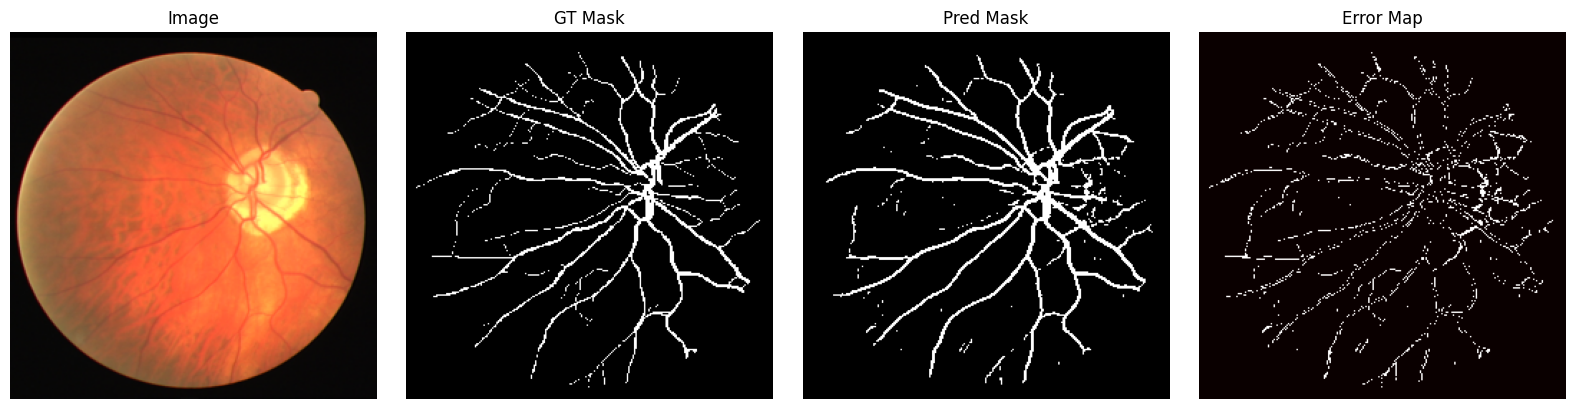

In [3]:
import random
import torch
import matplotlib.pyplot as plt
import numpy as np

from datasets.drive_dataset import DriveDataset
from models.resunet import ResUNet


def predict():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device:", device)

    # ===== 1. 加载数据 =====
    dataset = DriveDataset(
        root_dir=r"E:\CS\PostG\个人\unet_learn\DRIVE\training",
        image_size=256,
        is_train=False
    )

    idx = random.randint(0, len(dataset) - 1)
    #idx = 0
    print("sample index:", idx)

    img, gt_mask = dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)

    # ===== 2. 加载模型 =====
    model = ResUNet(num_classes=1).to(device)

    weight_path = r"E:\CS\PostG\个人\unet_learn\checkpoints\best_resunet_tversky_aug_drive.pth"

    model.load_state_dict(
        torch.load(weight_path, map_location=device)
    )
    model.eval()

    # ===== 3. 推理 =====
    with torch.no_grad():
        logits = model(img_tensor)
        prob = torch.sigmoid(logits)
        pred_mask = (prob > 0.5).float()

    # ===== 4. 转 CPU =====
    img_np = img.permute(1, 2, 0).cpu().numpy()
    gt_np = gt_mask.squeeze(0).cpu().numpy()
    pred_np = pred_mask.squeeze().cpu().numpy()

    error_map = (pred_np != gt_np).astype(np.float32)

    # ===== 5. 可视化 =====
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.title("Image")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("GT Mask")
    plt.imshow(gt_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Pred Mask")
    plt.imshow(pred_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Error Map")
    plt.imshow(error_map, cmap="hot")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    predict()